# Lab 2: PMV, PPD and operative temperature (ISO 7730)

**Goal.** Compute the thermal-comfort indices for the summer day (outdoor air), then find indoor conditions with $-0.5 < PMV < 0.5$.

| Symbol | Meaning | Unit |
|---|---|---|
| $t_a$ | air temperature | °C |
| $t_{mr}$ | mean radiant temperature (average temperature of the surrounding surfaces) | °C |
| $v$ | relative air speed | m/s |
| $RH$ | relative humidity | % |
| $I_{clo}$ | clothing insulation (1 clo = 0.155 m²·K/W) | clo |
| $M_{met}$ | metabolic rate (1 met = 58.15 W/m², a person sitting at rest) | met |
| $PMV$ | Predicted Mean Vote, scale −3 (cold) … 0 (neutral) … +3 (hot) | – |
| $PPD$ | Predicted Percentage Dissatisfied | % |
| $t_o$ | operative temperature | °C |

All heat flows are per m² of body surface (W/m²).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from calculate_pmv_ppd import calculate_pmv_ppd, operative_temperature

## Step 2: unit conversions

- $M = M_{met}\cdot 58.15$ [W/m²]: metabolic heat produced per m² of skin.
- $I_{cl} = 0.155\cdot I_{clo}$ [m²·K/W]: thermal resistance of the clothes.
- $p_{sat}(t_a) = e^{16.6536-\frac{4030.183}{t_a+235}}$ [kPa] (Antoine equation): the maximum water-vapour pressure air can hold at $t_a$.
- $p_v = \frac{RH}{100}\cdot p_{sat}\cdot 1000$ [Pa]: the actual vapour pressure. Humid air ($p_v$ high) slows sweat evaporation, so you feel warmer.
- $f_{cl}=1+1.29\,I_{cl}$ if $I_{cl}<0.078$, else $1.05+0.645\,I_{cl}$ [–]: clothed area / nude area. Clothes enlarge the surface that exchanges heat.

In [2]:
t_a, t_mr, v, rh, i_clo, m_met = 30, 30.5, 0.15, 60, 0.5, 1.2   # summer day, outdoor air

M     = m_met * 58.15                                   # W/m2
I_cl  = 0.155 * i_clo                                   # m2.K/W
p_sat = np.exp(16.6536 - 4030.183 / (t_a + 235)) * 1000 # Pa
p_v   = rh / 100 * p_sat                                # Pa
f_cl  = 1 + 1.29 * I_cl if I_cl < 0.078 else 1.05 + 0.645 * I_cl
print(f"M={M:.2f} W/m2  I_cl={I_cl:.4f} m2K/W  p_sat={p_sat:.0f} Pa  p_v={p_v:.0f} Pa  f_cl={f_cl:.3f}")

M=69.78 W/m2  I_cl=0.0775 m2K/W  p_sat=4243 Pa  p_v=2546 Pa  f_cl=1.100


## Step 3: clothing surface temperature $t_{cl}$ (iteration)

The clothes pass heat from the skin (≈ 35.7 °C minus a term for the work done by the body) to the room. In steady state:

$$t_{cl} = 35.7 - 0.028\,M - I_{cl}\,(RL_5 + RL_6)$$

but $RL_5$ and $RL_6$ themselves depend on $t_{cl}$, so we guess, recompute and repeat (ISO 7730 scheme, working with $x=T_{cl}/100$ in K/100). We stop when the old and new $x$ differ by less than $\epsilon = 0.0015$, i.e. 0.15 K. Averaging old and new value keeps the iteration stable. Kelvin conversion uses 273.15.

Convection coefficient [W/(m²·K)]: $h_c=\max(h_{c,f},h_{c,n})$ with forced $h_{c,f}=12.1\sqrt v$ (driven by air speed) and natural $h_{c,n}=2.38\,|t_{cl}-t_a|^{0.25}$ (driven by the temperature difference).

## Step 4: the six heat-loss paths [W/m²]

| Path | Formula | Physical meaning |
|---|---|---|
| $RL_1$ | $3.05\cdot10^{-3}(5733-6.99M-p_v)$ | vapour diffusing through the skin |
| $RL_2$ | $0.42(M-58.15)$, only if $M>58.15$ | regulatory sweating |
| $RL_3$ | $1.7\cdot10^{-5}M(5867-p_v)$ | latent heat of breathing (moisture exhaled) |
| $RL_4$ | $0.0014\,M(34-t_a)$ | dry heat of breathing (warming inhaled air) |
| $RL_5$ | $3.96 f_{cl}[(T_{cl}/100)^4-(T_{mr}/100)^4]$ | radiation clothes → room surfaces (temps in **K**) |
| $RL_6$ | $f_{cl}\,h_c\,(t_{cl}-t_a)$ | convection clothes → room air |

## Step 5: PMV and PPD

$$TS = 0.303\,e^{-0.036M}+0.028 \;[\mathrm{m^2/W}],\qquad L = M-\sum_{i=1}^{6}RL_i \;[\mathrm{W/m^2}],\qquad PMV = TS\cdot L$$

$L>0$: the body produces more heat than it loses, so it feels warm (PMV > 0). $L<0$: it feels cold.

$$PPD = 100-95\,e^{-0.03353\,PMV^4-0.2179\,PMV^2}\;[\%]$$

PPD never drops below 5 %: even at PMV = 0 some people are unhappy.

## Step 6: operative temperature

$t_o = A\,t_a+(1-A)\,t_{mr}$ with $A=0.5$ for $v<0.2$ m/s, $0.6$ for $0.2\le v<0.6$, $0.7$ for $v\ge0.6$. More air movement gives air temperature more weight.

## Part 1: outdoor summer day

In [3]:
pmv, ppd, t_o, n = calculate_pmv_ppd(t_a, t_mr, v=v, rh=rh, i_clo=i_clo, m_met=m_met)
print(f"PMV= {pmv:.3f}", f"PPD= {ppd:.1f} %", f"t_o= {t_o:.2f} degC", f"n iterations= {n}", sep=chr(10))

PMV= 1.767
PPD= 65.3 %
t_o= 30.25 degC
n iterations= 8


PMV ≈ 1.7 means "warm to hot" and about 62 % of people are dissatisfied.

> **Check against the sheet.** The lab sheet gives PMV = 1.767, PPD = 65.3 %, $t_o$ = 30.25 °C, $n$ = 8. The code reproduces all four.

## Visual guide: how the parameters and terms relate

Each chart below answers one question. Colours: blue = main series, orange = comparison or "too hot", grey = reference. The outdoor summer day is the baseline unless stated.

In [4]:
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"   # categorical slots 1-3
INK, MUTED, GRID, BAND = "#0b0b0b", "#52514e", "#e4e3df", "#ecebe7"
plt.rcParams.update({"axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
                     "text.color": INK, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
                     "figure.dpi": 110, "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold"})
BASE = dict(t_a=30, t_mr=30.5, v=0.15, rh=60, i_clo=0.5, m_met=1.2)   # outdoor summer day
*_, d = calculate_pmv_ppd(**BASE, details=True)

### 1. Where does the body's heat go? (heat balance)

The body produces $M$ [W/m²]. Six paths carry heat away. What is **left over** is the thermal load $L$. The sensation coefficient $TS$ turns that surplus into a vote: $PMV = TS\cdot L$. In a perfectly comfortable room $L \approx 0$ (production = losses).

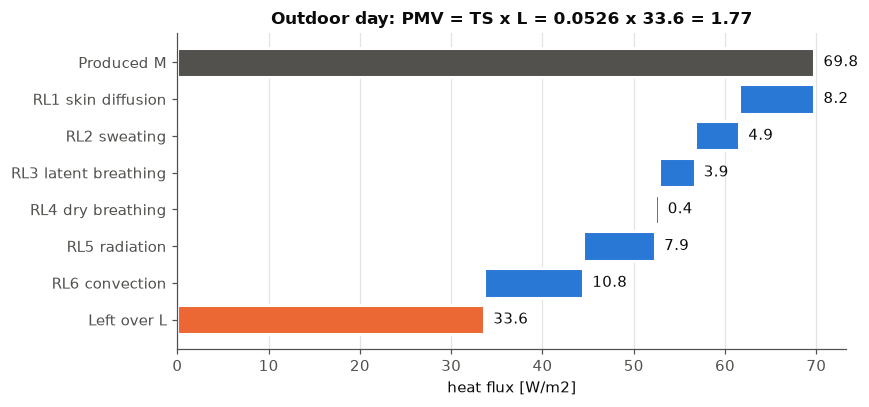

In [5]:
names = ["Produced M", "RL1 skin diffusion", "RL2 sweating", "RL3 latent breathing",
         "RL4 dry breathing", "RL5 radiation", "RL6 convection", "Left over L"]
losses = [d["RL1"], d["RL2"], d["RL3"], d["RL4"], d["RL5"], d["RL6"]]
left, widths, colors = [0], [d["M"]], [MUTED]
level = d["M"]
for x in losses:                       # waterfall: each loss bar starts where the previous one ended
    level -= x
    left.append(level); widths.append(x); colors.append(BLUE)
left.append(0); widths.append(d["L"]); colors.append(ORANGE)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(names, widths, left=left, color=colors, edgecolor="white", linewidth=2)
for i, (l, w) in enumerate(zip(left, widths)):
    ax.text(l + w + 1, i, f"{w:.1f}", va="center", color=INK)
ax.invert_yaxis(); ax.set_xlabel("heat flux [W/m2]")
ax.set_title(f"Outdoor day: PMV = TS x L = {d['ts']:.4f} x {d['L']:.1f} = {d['ts']*d['L']:.2f}")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

**Reading it.** Grey = heat produced, blue = heat lost through each path, orange = surplus that is not removed, so the person feels warm. Radiation and convection (the "dry" paths) lose the most. They shrink when the room is as warm as the skin, which is exactly why hot rooms give a positive PMV.

### 2. The iteration for $t_{cl}$: how fast does it converge?

$t_{cl}$ appears on both sides of its own equation, so we start from a guess and refine it. Each pass changes it less than the previous one.

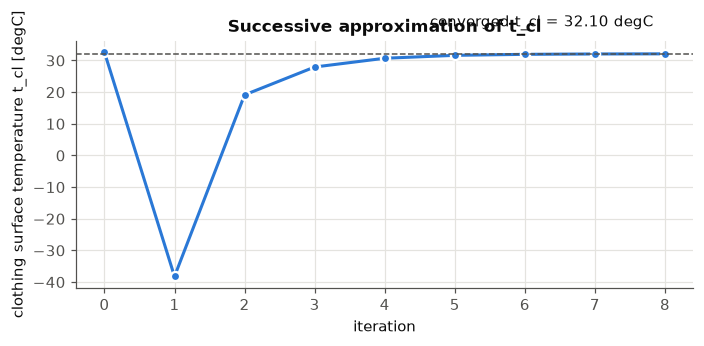

In [6]:
h = d["history"]
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(range(len(h)), h, "-o", color=BLUE, lw=2, ms=6, mec="white", mew=1.5)
ax.axhline(h[-1], color=MUTED, lw=1, ls="--")
ax.annotate(f"converged t_cl = {h[-1]:.2f} degC", (len(h) - 1, h[-1]), xytext=(-8, 18),
            textcoords="offset points", ha="right", color=INK)
ax.set_xlabel("iteration"); ax.set_ylabel("clothing surface temperature t_cl [degC]")
ax.set_title("Successive approximation of t_cl")
plt.tight_layout(); plt.show()

**Reading it.** Iteration 0 is the initial estimate. The curve flattens: we stop when the change falls below $\epsilon$ (here after 8 passes). The clothes sit between skin (≈ 34–35 °C) and air (30 °C), at about 32 °C.

### 3. Forced vs natural convection: which one wins?

$h_c=\max(h_{c,f},h_{c,n})$. Forced convection grows with air speed $v$; natural convection depends only on the clothes–air temperature difference. At low speed buoyancy wins, above a threshold the moving air wins.

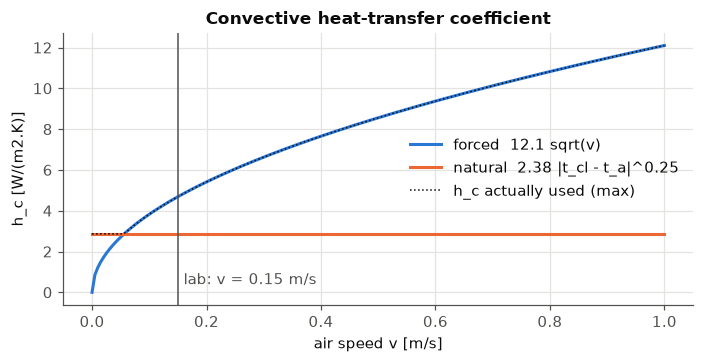

In [7]:
v_axis = np.linspace(0, 1.0, 200)
hf = 12.1 * np.sqrt(v_axis)                                   # forced [W/m2.K]
hn = np.full_like(v_axis, 2.38 * abs(d["t_cl"] - BASE["t_a"]) ** 0.25)   # natural at the baseline t_cl - t_a
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(v_axis, hf, color=BLUE, lw=2, label="forced  12.1 sqrt(v)")
ax.plot(v_axis, hn, color=ORANGE, lw=2, label="natural  2.38 |t_cl - t_a|^0.25")
ax.plot(v_axis, np.maximum(hf, hn), color=INK, lw=1, ls=":", label="h_c actually used (max)")
ax.axvline(BASE["v"], color=MUTED, lw=1); ax.text(BASE["v"] + 0.01, 0.4, "lab: v = 0.15 m/s", color=MUTED)
ax.set_xlabel("air speed v [m/s]"); ax.set_ylabel("h_c [W/(m2.K)]"); ax.legend(frameon=False)
ax.set_title("Convective heat-transfer coefficient")
plt.tight_layout(); plt.show()

**Reading it.** The crossover is at a very low speed (about 0.06 m/s), so for any normal room air speed forced convection is the one used. Higher $h_c$ means more convective loss $RL_6$, so a breeze lowers PMV.

### 4. Sensitivity: what moves PMV the most?

Each panel varies **one** parameter and keeps the others at the baseline (dot = outdoor day). The grey band is the comfort zone $-0.5<PMV<0.5$.

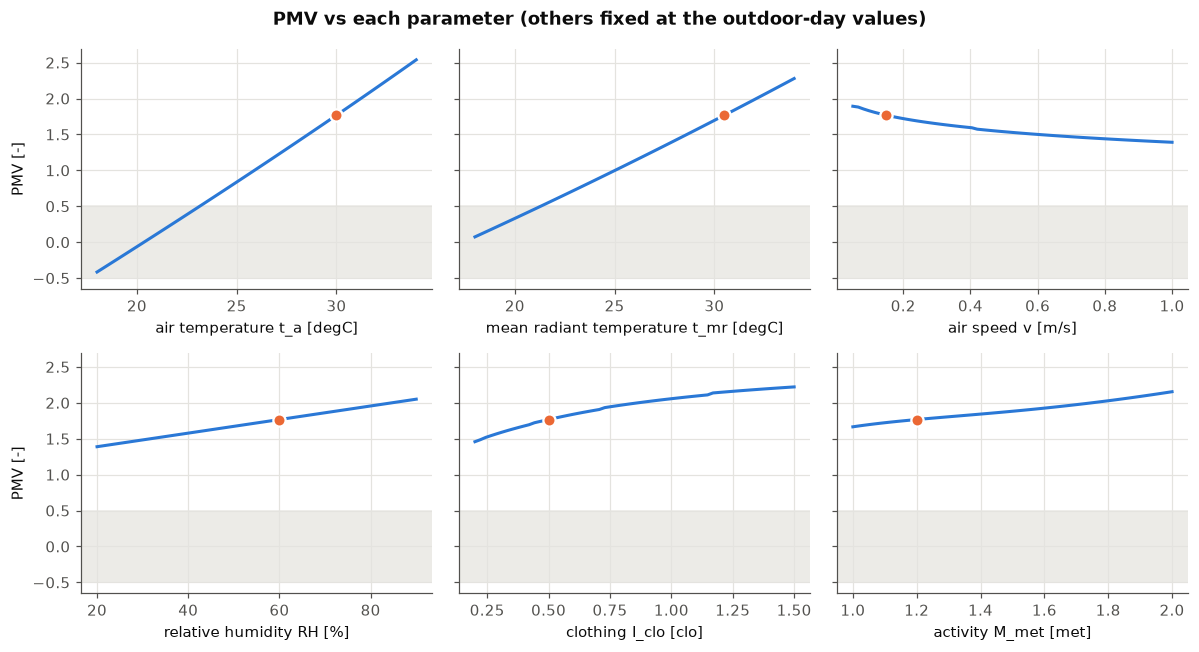

,step,change in PMV
t_a,1.0,0.190
t_mr,1.0,0.144
v,0.1,-0.085
rh,10.0,0.095
i_clo,0.1,0.073
m_met,0.1,0.039


In [8]:
sweeps = {  # parameter: (values, axis label)
    "t_a":   (np.linspace(18, 34, 60), "air temperature t_a [degC]"),
    "t_mr":  (np.linspace(18, 34, 60), "mean radiant temperature t_mr [degC]"),
    "v":     (np.linspace(0.05, 1.0, 60), "air speed v [m/s]"),
    "rh":    (np.linspace(20, 90, 60), "relative humidity RH [%]"),
    "i_clo": (np.linspace(0.2, 1.5, 60), "clothing I_clo [clo]"),
    "m_met": (np.linspace(1.0, 2.0, 60), "activity M_met [met]"),
}
fig, axes = plt.subplots(2, 3, figsize=(11, 6), sharey=True)
for ax, (p, (xs, lab)) in zip(axes.ravel(), sweeps.items()):
    ys = [calculate_pmv_ppd(**{**BASE, p: x})[0] for x in xs]
    ax.axhspan(-0.5, 0.5, color=BAND, zorder=0)
    ax.plot(xs, ys, color=BLUE, lw=2)
    ax.plot(BASE[p], calculate_pmv_ppd(**BASE)[0], "o", color=ORANGE, ms=8, mec="white", mew=1.5)
    ax.set_xlabel(lab)
axes[0, 0].set_ylabel("PMV [-]"); axes[1, 0].set_ylabel("PMV [-]")
fig.suptitle("PMV vs each parameter (others fixed at the outdoor-day values)", fontweight="bold")
plt.tight_layout(); plt.show()

step = {"t_a": 1, "t_mr": 1, "v": 0.1, "rh": 10, "i_clo": 0.1, "m_met": 0.1}
p0 = calculate_pmv_ppd(**BASE)[0]
pd.DataFrame({"step": step, "change in PMV": {p: round(calculate_pmv_ppd(**{**BASE, p: BASE[p] + s})[0] - p0, 3)
                                               for p, s in step.items()}})

**Reading it.** Look at the sign and size of each line, and at the table of PMV change for a typical step.
- Higher $t_a$, $t_{mr}$, humidity, clothing and activity push PMV **up** (more heat kept or produced, or less evaporation). Higher air speed pushes it **down** (more convective loss).
- Ranking for a typical step: $t_a$ (+0.19 per °C) > $t_{mr}$ (+0.14 per °C) > humidity (+0.10 per 10 %) > air speed (−0.09 per 0.1 m/s) > clothing (+0.07 per 0.1 clo) > activity (+0.04 per 0.1 met).
- $t_a$ and $t_{mr}$ both enter through radiation and convection, so they are the main levers. $t_a$ also enters the dry breathing term and the vapour pressure.
- No single lever brings the outdoor day (PMV 1.77) into the grey band except a large drop in $t_a$ (about 6 °C), which is why the indoor solution cools the air.

### 5. From PMV to PPD

PPD $=100-95\,e^{-0.03353\,PMV^4-0.2179\,PMV^2}$ is symmetric (too cold is as bad as too hot) and **never below 5 %**.

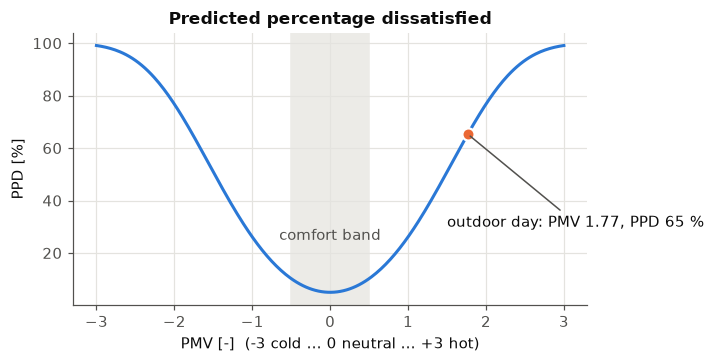

In [9]:
x = np.linspace(-3, 3, 300)
ppd_curve = 100 - 95 * np.exp(-0.03353 * x**4 - 0.2179 * x**2)
pmv0, ppd0, *_ = calculate_pmv_ppd(**BASE)
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.axvspan(-0.5, 0.5, color=BAND, zorder=0)
ax.plot(x, ppd_curve, color=BLUE, lw=2)
ax.plot(pmv0, ppd0, "o", color=ORANGE, ms=8, mec="white", mew=1.5)
ax.annotate(f"outdoor day: PMV {pmv0:.2f}, PPD {ppd0:.0f} %", (pmv0, ppd0), xytext=(1.5, 30),
            textcoords="data", ha="left", arrowprops=dict(arrowstyle="-", color=MUTED))
ax.text(0, 25, "comfort band", ha="center", color=MUTED)
ax.set_xlabel("PMV [-]  (-3 cold ... 0 neutral ... +3 hot)"); ax.set_ylabel("PPD [%]")
ax.set_title("Predicted percentage dissatisfied")
plt.tight_layout(); plt.show()

### 6. Comfort map: temperature × humidity

Colour = PMV (blue = cool side, grey = neutral, orange = warm side). The black lines are the comfort limits $PMV=\pm0.5$. Here $t_{mr}=t_a+0.5$ as in the lab.

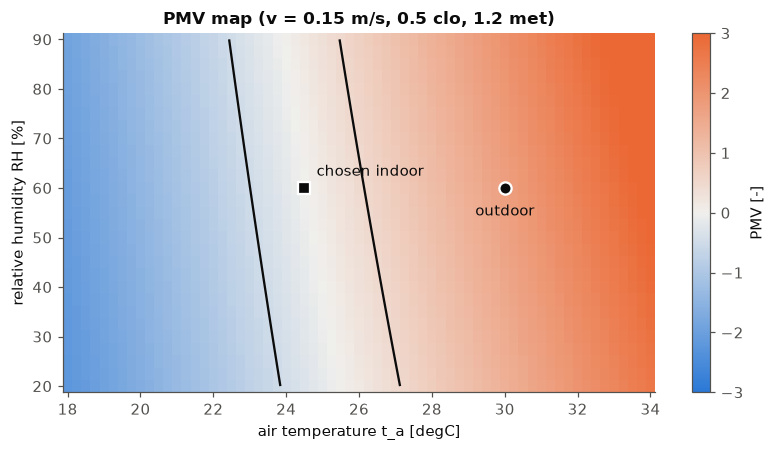

In [10]:
ta_g = np.arange(18, 34.01, 0.25); rh_g = np.arange(20, 90.1, 2.5)
Z = np.array([[calculate_pmv_ppd(t, t + 0.5, rh=r)[0] for t in ta_g] for r in rh_g])
cmap = LinearSegmentedColormap.from_list("div", [BLUE, "#f0efec", ORANGE])
fig, ax = plt.subplots(figsize=(7.5, 4.2))
im = ax.pcolormesh(ta_g, rh_g, Z, cmap=cmap, norm=TwoSlopeNorm(0, vmin=-3, vmax=3), shading="auto")
ax.contour(ta_g, rh_g, Z, levels=[-0.5, 0.5], colors=INK, linewidths=1.5, linestyles="solid")
ax.plot(30, 60, "o", color=INK, ms=8, mec="white", mew=1.5); ax.annotate("outdoor", (30, 60), xytext=(0, -18), textcoords="offset points", ha="center")
ax.plot(24.5, 60, "s", color=INK, ms=8, mec="white", mew=1.5); ax.annotate("chosen indoor", (24.5, 60), xytext=(8, 8), textcoords="offset points")
ax.set_xlabel("air temperature t_a [degC]"); ax.set_ylabel("relative humidity RH [%]"); ax.grid(False)
fig.colorbar(im, label="PMV [-]"); ax.set_title("PMV map (v = 0.15 m/s, 0.5 clo, 1.2 met)")
plt.tight_layout(); plt.show()

**Reading it.** The comfort region is the band between the two black lines. It tilts slightly: when the air is more humid, the same temperature feels warmer, so the comfortable temperature drops a little. Our indoor choice (square) lies inside it, the outdoor day (circle) is far on the warm side.

### 7. Operative temperature weights

$t_o=A\,t_a+(1-A)\,t_{mr}$. The weight $A$ of the air temperature steps up as air speed rises, because moving air strengthens convection relative to radiation.

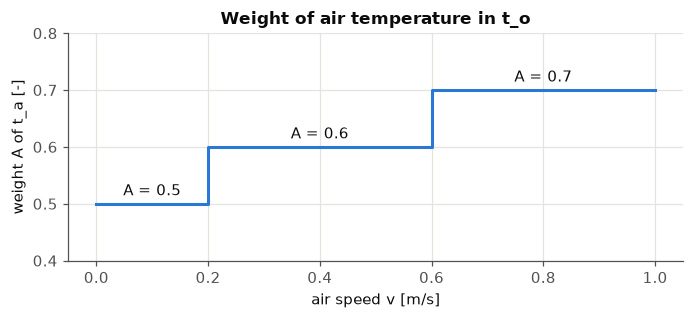

In [11]:
v_axis = np.linspace(0, 1, 400)
A = np.where(v_axis < 0.2, 0.5, np.where(v_axis < 0.6, 0.6, 0.7))
fig, ax = plt.subplots(figsize=(6.5, 3))
ax.step(v_axis, A, color=BLUE, lw=2, where="post")
for v_, a_ in ((0.1, 0.5), (0.4, 0.6), (0.8, 0.7)):
    ax.text(v_, a_ + 0.015, f"A = {a_}", ha="center")
ax.set_ylim(0.4, 0.8); ax.set_xlabel("air speed v [m/s]"); ax.set_ylabel("weight A of t_a [-]")
ax.set_title("Weight of air temperature in t_o")
plt.tight_layout(); plt.show()

**Reading it.** The lab case has $v=0.15<0.2$, so $A=0.5$ and $t_o$ is the plain average of $t_a$ and $t_{mr}$: $0.5\cdot30+0.5\cdot30.5=30.25$ °C.

## Part 2: indoor conditions with $-0.5<PMV<0.5$

Same $RH$, $v$, clothing and activity. Only $t_a$ and $t_{mr}$ change. Sweep $t_a$ with $t_{mr}=t_a+0.5$ °C.

-0.5 < PMV < 0.5 for t_a from 23.25 to 26.0 degC (t_mr = t_a + 0.5)


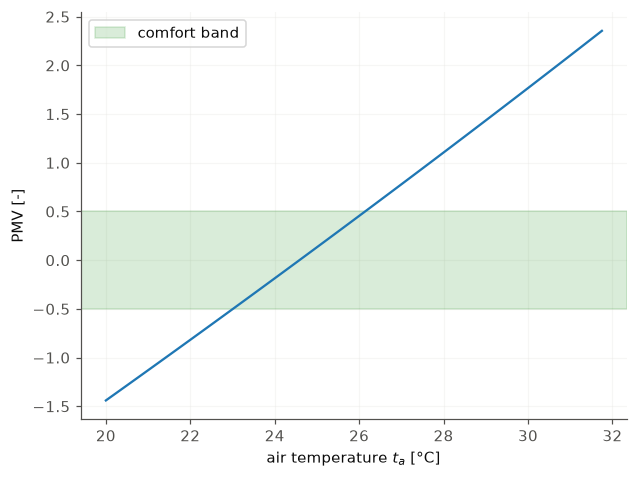

In [12]:
ta_range = np.arange(20, 32, 0.25)
pmv_curve = np.array([calculate_pmv_ppd(t, t + 0.5)[0] for t in ta_range])
ok = ta_range[np.abs(pmv_curve) < 0.5]
print(f"-0.5 < PMV < 0.5 for t_a from {ok.min()} to {ok.max()} degC (t_mr = t_a + 0.5)")

plt.plot(ta_range, pmv_curve)
plt.axhspan(-0.5, 0.5, color="green", alpha=0.15, label="comfort band")
plt.xlabel("air temperature $t_a$ [°C]"); plt.ylabel("PMV [-]"); plt.legend(); plt.grid(alpha=.3)
plt.show()

In [13]:
t_a_in, t_mr_in = 24.5, 25          # chosen: PMV close to 0, t_mr = t_a + 0.5
pmv, ppd, t_o, n = calculate_pmv_ppd(t_a_in, t_mr_in, v=0.15, rh=60, i_clo=0.5, m_met=1.2)
print(f"t_a={t_a_in}  t_mr={t_mr_in}", f"PMV= {pmv:.3f}", f"PPD= {ppd:.1f} %", f"t_o= {t_o:.2f} degC", f"n iterations= {n}", sep=chr(10))

t_a=24.5  t_mr=25
PMV= -0.027
PPD= 5.0 %
t_o= 24.75 degC
n iterations= 8


**Answer.** $t_a = 24.5$ °C, $t_{mr}=25$ °C gives PMV ≈ −0.03 and PPD ≈ 5 %, practically neutral. Any $t_a$ from about 23.25 to 26 °C (with $t_{mr}=t_a+0.5$) stays inside the ±0.5 band. The outdoor air (30 °C) is about 5 °C too hot, which is why cooling is needed in summer.